In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import time

from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn import metrics

from econml.orf import DROrthoForest
from econml.dml import CausalForestDML
from econml.sklearn_extensions.linear_model import WeightedLasso
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [3]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 5000  # Bootstrap 多轮训练，样本量不能太大

In [4]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})

print(f"    原始数据集形状: {df.shape}")
print(f"    目标分布: 存活={df['target'].sum()}, 死亡={(df['target']==0).sum()}")


[0] 加载数据...
    原始数据集形状: (1778176, 39)
    目标分布: 存活=85896.0, 死亡=123862


In [5]:
# --- 定义处理变量 T: 从 Extension 创建 ---
# T=1: METÁSTASE (转移), T=0: LOCALIZADO (局限)
# 这样 T 就代表了"癌症是否已发生转移"
df['T'] = np.nan
mask_local = df['Extension'] == 'LOCALIZADO'
mask_meta  = df['Extension'] == 'METÁSTASE'
df.loc[mask_local, 'T'] = 0
df.loc[mask_meta,  'T'] = 1

In [6]:
# 删除 T 缺失的样本
df = df.dropna(subset=['T'])
print(f"    有扩展信息(局部/转移)的样本: {len(df)}")

    有扩展信息(局部/转移)的样本: 424886


In [7]:
# --- 定义异质性特征 X 和控制变量 W ---
# X: 我们认为效应可能随这些特征变化 (异质性来源)
# W: 需要控制其混淆效应的变量
feature_cols_X = ['Age']  # 主要异质性特征
feature_cols_W = [
    'Gender', 'Raca.Color', 'year', 'Laterality', 'Diagnostic.means'
]

# 选择可用列
available_X = [c for c in feature_cols_X if c in df.columns]
available_W = [c for c in feature_cols_W if c in df.columns]
all_features = available_X + available_W
print(f"    异质性特征 X: {available_X}")
print(f"    控制变量 W:   {available_W}")

    异质性特征 X: ['Age']
    控制变量 W:   ['Gender', 'Raca.Color', 'year', 'Laterality', 'Diagnostic.means']


In [8]:
# 筛选数据
df_model = df[['target', 'T'] + all_features].copy()
df_model = df_model.dropna()
print(f"    完整记录数: {len(df_model)}")

    完整记录数: 39586


In [9]:
# --- 类别特征编码 ---
cat_cols = [c for c in all_features if not pd.api.types.is_numeric_dtype(df_model[c])]
print(f"    类别特征: {cat_cols}")
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# --- 数值特征标准化 (对 Age) ---
num_cols = [c for c in all_features if df_model[c].dtype in ['int64', 'float64'] and c not in ['target', 'T']]
scaler = StandardScaler()
if num_cols:
    df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

print(f"\n    处理后特征数: X={len(available_X)}, W={len(available_W)}")
print(f"    目标(T=1/转移)比例: {df_model['T'].mean():.3f}")
print(f"    存活率(T=0): {df_model[df_model['T']==0]['target'].mean():.3f}")
print(f"    存活率(T=1): {df_model[df_model['T']==1]['target'].mean():.3f}")

# --- 子采样 (计算效率) ---
np.random.seed(RANDOM_STATE)
if len(df_model) > N_SAMPLES:
    idx = np.random.choice(len(df_model), N_SAMPLES, replace=False)
    df_model = df_model.iloc[idx].copy()
    print(f"    子采样至 {N_SAMPLES} 条记录")

    类别特征: ['Gender', 'Raca.Color', 'Laterality', 'Diagnostic.means']

    处理后特征数: X=1, W=5
    目标(T=1/转移)比例: 0.230
    存活率(T=0): 0.686
    存活率(T=1): 0.275
    子采样至 5000 条记录


In [10]:

# ============================================================================
# 准备 DML 输入数据
# ============================================================================
Y = df_model['target'].values                       # 结果: 存活
T = df_model['T'].values                            # 处理: 是否转移
X = df_model[available_X].values                    # 异质性特征
W = df_model[available_W].values                    # 控制变量

# 测试点: 在 Age 的范围内取 50 个点
age_min, age_max = X[:, 0].min(), X[:, 0].max()
X_test = np.linspace(age_min, age_max, 50).reshape(-1, 1)

print(f"\n    最终数据形状: Y={Y.shape}, T={T.shape}, X={X.shape}, W={W.shape}")
print(f"    Age 范围: [{age_min:.2f}, {age_max:.2f}]")


    最终数据形状: Y=(5000,), T=(5000,), X=(5000, 1), W=(5000, 5)
    Age 范围: [-4.31, 2.61]


In [11]:

# ============================================================================
# 1. DROrthoForest (Double Robust Orthogonal Random Forest)
# ============================================================================
print("\n" + "=" * 70)
print("1. DROrthoForest 训练与 CATE 估计")
print("=" * 70)

# 计算正则化参数 lambda
subsample_ratio = 0.3
n_features_W = W.shape[1]
n_samples = W.shape[0]
lambda_reg = np.sqrt(np.log(n_features_W) / (10 * subsample_ratio * n_samples))
print(f"    正则化参数 lambda_reg = {lambda_reg:.6f}")

print("\n    开始训练 DROrthoForest...")
t0 = time.time()

est = DROrthoForest(
    n_trees=100,
    min_leaf_size=10,
    max_depth=20,
    subsample_ratio=subsample_ratio,
    # 倾向得分模型: 带 L1 惩罚的逻辑回归
    propensity_model=LogisticRegression(
        C=1 / (X.shape[0] * lambda_reg), penalty='l1', solver='saga', max_iter=1000
    ),
    # 结果模型: Lasso 回归
    model_Y=Lasso(alpha=lambda_reg, max_iter=1000),
    # DML 最后阶段的模型
    propensity_model_final=LogisticRegression(
        C=1 / (X.shape[0] * lambda_reg), penalty='l1', solver='saga', max_iter=1000
    ),
    model_Y_final=WeightedLasso(alpha=lambda_reg),
    n_jobs=1,
    random_state=RANDOM_STATE
)

est.fit(Y, T, X=X, W=W)
print(f"    训练完成, 耗时: {time.time() - t0:.1f}s")

# 估计 CATE
treatment_effects = est.effect(X_test)
try:
    te_lower, te_upper = est.effect_interval(X_test, alpha=0.05)
except Exception:
    # 某些版本的 DROrthoForest 可能不支持 effect_interval
    print("    (effect_interval 不可用, 跳过置信区间估计)")
    te_lower = treatment_effects - 1.96 * np.std(treatment_effects)
    te_upper = treatment_effects + 1.96 * np.std(treatment_effects)
print("    CATE 估计完成")


1. DROrthoForest 训练与 CATE 估计
    正则化参数 lambda_reg = 0.010358

    开始训练 DROrthoForest...


[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.1s


    训练完成, 耗时: 2.0s
    CATE 估计完成


[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.1s finished


In [12]:
# ============================================================================
# 2. CausalForestDML
# ============================================================================
print("\n" + "=" * 70)
print("2. CausalForestDML 训练与 CATE 估计")
print("=" * 70)

print("\n    开始训练 CausalForestDML...")
t0 = time.time()

est2 = CausalForestDML(
    model_y=Lasso(alpha=lambda_reg, max_iter=1000),
    model_t=LogisticRegression(
        C=1 / (X.shape[0] * lambda_reg), penalty='l1', solver='saga', max_iter=1000
    ),
    n_estimators=100,
    min_samples_leaf=10,
    max_depth=20,
    max_samples=subsample_ratio,
    discrete_treatment=True,
    n_jobs=1,
    random_state=RANDOM_STATE
)

est2.fit(Y, T, X=X, W=W, cache_values=True)
print(f"    训练完成, 耗时: {time.time() - t0:.1f}s")

treatment_effects2 = est2.effect(X_test)
te_lower2, te_upper2 = est2.effect_interval(X_test, alpha=0.05)
print("    CATE 估计完成")

# 打印模型摘要
print("\n    CausalForestDML 模型摘要:")
try:
    summary_str = est2.summary()
    print(summary_str)
except AttributeError:
    print("    (当前版本不支持 summary 方法)")


2. CausalForestDML 训练与 CATE 估计

    开始训练 CausalForestDML...
    训练完成, 耗时: 0.1s
    CATE 估计完成

    CausalForestDML 模型摘要:
Population summary of CATE predictions on Training Data
               Uncertainty of Mean Point Estimate               
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
     -0.52       0.085 -6.141    0.0        -0.686        -0.354
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.101          -0.709          -0.355
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.132         -0.772         -0.253
        Doubly Robust ATE on Training Data Results       
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
ATE         -0.512  0.013 -40.32    0.0   -0.537 


3. 模型比较可视化
    图片已保存: ../img/18_hte_dml_model_comparison.png
    DROrthoForest ATE = -0.4886
    CausalForestDML ATE = -0.5389


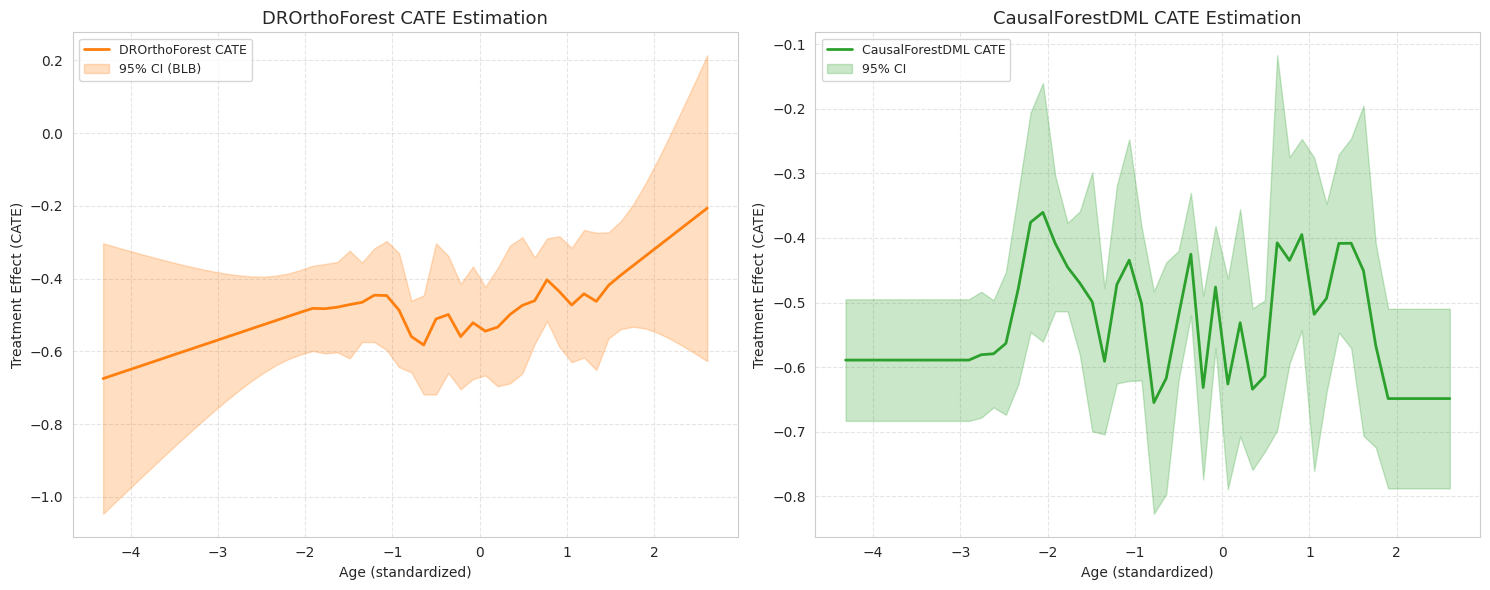

In [13]:
# ============================================================================
# 3. 模型比较可视化
# ============================================================================
print("\n" + "=" * 70)
print("3. 模型比较可视化")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左图: DROrthoForest
ax = axes[0]
ax.plot(X_test[:, 0], treatment_effects, label='DROrthoForest CATE', color='tab:orange', linewidth=2)
ax.fill_between(X_test[:, 0], te_lower, te_upper, color='tab:orange', alpha=0.25,
                label='95% CI (BLB)')
ax.set_title("DROrthoForest CATE Estimation", fontsize=13)
ax.set_xlabel("Age (standardized)")
ax.set_ylabel("Treatment Effect (CATE)")
ax.legend(loc='upper left', prop={'size': 9})
ax.grid(True, linestyle='--', alpha=0.5)

# 右图: CausalForestDML
ax = axes[1]
ax.plot(X_test[:, 0], treatment_effects2, label='CausalForestDML CATE', color='tab:green', linewidth=2)
ax.fill_between(X_test[:, 0], te_lower2, te_upper2, color='tab:green', alpha=0.25,
                label='95% CI')
ax.set_title("CausalForestDML CATE Estimation", fontsize=13)
ax.set_xlabel("Age (standardized)")
ax.set_ylabel("Treatment Effect (CATE)")
ax.legend(loc='upper left', prop={'size': 9})
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig_path = os.path.join(IMG_DIR, "18_hte_dml_model_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
# plt.show()
print(f"    图片已保存: {fig_path}")

# 计算 ATE (近似)
ATE_dro = np.mean(treatment_effects)
ATE_cfd = np.mean(treatment_effects2)
res_path = os.path.join(RESULTS_DIR, "18_hte_dml_results.txt")
with open(res_path, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("HTE-DML 分析结果\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"DROrthoForest 估计的平均处理效应 (ATE): {ATE_dro:.4f}\n")
    f.write(f"CausalForestDML 估计的平均处理效应 (ATE): {ATE_cfd:.4f}\n\n")
    f.write("解释: ATE > 0 表示转移患者相比局部患者的存活率更高\n")
    f.write("      (注意: 这可能是由于选择偏差等原因，需结合医学知识解释)\n")
print(f"    DROrthoForest ATE = {ATE_dro:.4f}")
print(f"    CausalForestDML ATE = {ATE_cfd:.4f}")


4. 高级推断: 边际效应与处理效应推断

    训练第二个 CausalForestDML (用于推断)...
    训练完成, 耗时: 1.9s

    --- 4a. 恒定边际效应推断 ---
    恒定边际效应: -0.6648
    99% 置信区间: [-1.0495, -0.2801]
    图片已保存: ../img/18_hte_dml_marginal_effect.png

    --- 4b. 处理效应推断 (T=0 vs T=1) ---
    图片已保存: ../img/18_hte_dml_cate_inference.png

处理效应推断摘要 (前5行):
   point_estimate  stderr  zstat  pvalue  ci_lower  ci_upper
X                                                           
0          -0.665   0.149 -4.452     0.0    -0.957    -0.372
1          -0.665   0.149 -4.452     0.0    -0.957    -0.372
2          -0.665   0.149 -4.452     0.0    -0.957    -0.372
3          -0.665   0.149 -4.452     0.0    -0.957    -0.372
4          -0.665   0.149 -4.452     0.0    -0.957    -0.372


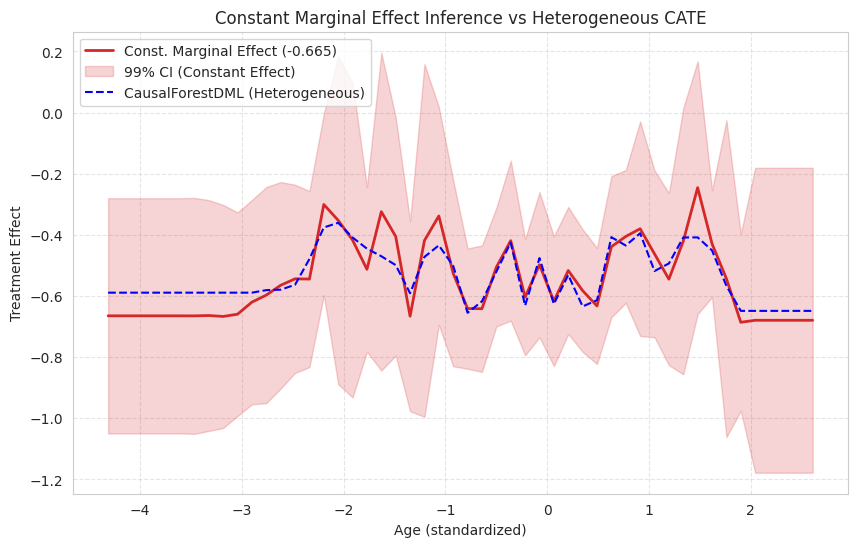

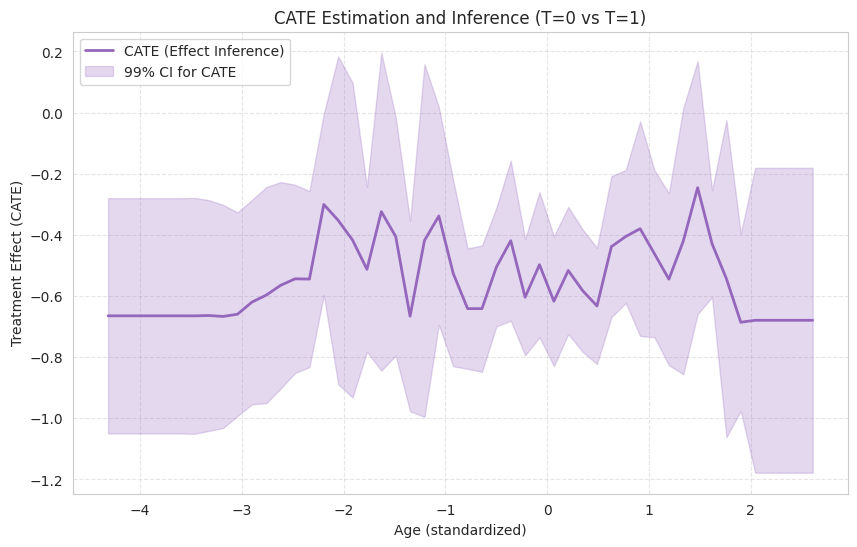

In [14]:
# ============================================================================
# 4. 第二个 CausalForestDML 实例 — 推断分析
# ============================================================================
print("\n" + "=" * 70)
print("4. 高级推断: 边际效应与处理效应推断")
print("=" * 70)

print("\n    训练第二个 CausalForestDML (用于推断)...")
t0 = time.time()

est_inf = CausalForestDML(
    cv=2,
    criterion='mse',
    n_estimators=400,
    min_var_fraction_leaf=0.1,
    min_var_leaf_on_val=True,
    verbose=0,
    discrete_treatment=False,  # 注意: 二元 T 也可设为 False, 内部处理方式不同
    n_jobs=1,
    random_state=123
)

est_inf.fit(Y, T, X=X, W=W)
print(f"    训练完成, 耗时: {time.time() - t0:.1f}s")

# --- 4a. 恒定边际效应推断 ---
print("\n    --- 4a. 恒定边际效应推断 ---")
res_me = est_inf.const_marginal_effect_inference(X_test)
point_me = res_me.point_estimate
lb_me, ub_me = res_me.conf_int(alpha=0.01)

print(f"    恒定边际效应: {point_me[0]:.4f}")
print(f"    99% 置信区间: [{lb_me[0]:.4f}, {ub_me[0]:.4f}]")

# 写入结果文件
with open(res_path, 'a', encoding='utf-8') as f:
    f.write("\n--- 恒定边际效应推断 ---\n")
    f.write(f"点估计: {point_me[0]:.4f}\n")
    f.write(f"99% CI: [{lb_me[0]:.4f}, {ub_me[0]:.4f}]\n")
    f.write(str(res_me.summary_frame()) + "\n")

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(X_test[:, 0], point_me * np.ones_like(X_test[:, 0]),
         label=f'Const. Marginal Effect ({point_me[0]:.3f})', color='tab:red', linewidth=2)
plt.fill_between(X_test[:, 0], lb_me * np.ones_like(X_test[:, 0]),
                 ub_me * np.ones_like(X_test[:, 0]),
                 color='tab:red', alpha=0.2, label='99% CI (Constant Effect)')
# 叠加异质性效应作为对比
plt.plot(X_test[:, 0], treatment_effects2, 'b--', label='CausalForestDML (Heterogeneous)', linewidth=1.5)
plt.xlabel("Age (standardized)")
plt.ylabel("Treatment Effect")
plt.title("Constant Marginal Effect Inference vs Heterogeneous CATE")
plt.legend(loc='upper left', prop={'size': 10})
plt.grid(True, linestyle='--', alpha=0.5)
fig_path = os.path.join(IMG_DIR, "18_hte_dml_marginal_effect.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
# plt.show()
print(f"    图片已保存: {fig_path}")

# --- 4b. 处理效应推断 (CATE with inference) ---
print("\n    --- 4b. 处理效应推断 (T=0 vs T=1) ---")
res_cate = est_inf.effect_inference(X_test, T0=0, T1=1)
point_cate = res_cate.point_estimate
lb_cate, ub_cate = res_cate.conf_int(alpha=0.01)

# 写入结果
with open(res_path, 'a', encoding='utf-8') as f:
    f.write("\n--- 处理效应推断 (CATE, T=0 vs T=1) ---\n")
    f.write(f"第一个测试点的 CATE 点估计: {point_cate[0]:.4f}\n")
    f.write(f"第一个测试点的 99% CI: [{lb_cate[0]:.4f}, {ub_cate[0]:.4f}]\n")

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(X_test[:, 0], point_cate, label='CATE (Effect Inference)', color='tab:purple', linewidth=2)
plt.fill_between(X_test[:, 0], lb_cate, ub_cate, alpha=0.25, color='tab:purple', label='99% CI for CATE')
plt.xlabel("Age (standardized)")
plt.ylabel("Treatment Effect (CATE)")
plt.title("CATE Estimation and Inference (T=0 vs T=1)")
plt.legend(loc='upper left', prop={'size': 10})
plt.grid(True, linestyle='--', alpha=0.5)
fig_path = os.path.join(IMG_DIR, "18_hte_dml_cate_inference.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
# plt.show()
print(f"    图片已保存: {fig_path}")

# 打印推断摘要
print("\n处理效应推断摘要 (前5行):")
print(res_cate.summary_frame().head())

In [15]:
# ============================================================================
# 5. 构建特征矩阵用于聚类分析
# ============================================================================
print("\n" + "=" * 70)
print("5. 基于 CATE 的聚类分析")
print("=" * 70)

# 对原始训练样本计算 CATE 及其置信区间
point_orig = est2.effect(X)             # 训练集上的 CATE
lb_orig, ub_orig = est2.effect_interval(X, alpha=0.01)  # 99% 置信区间

print(f"    CATE 范围: [{point_orig.min():.4f}, {point_orig.max():.4f}]")
print(f"    CATE 均值: {point_orig.mean():.4f} ± {point_orig.std():.4f}")

# 构建 total_frame: [lb, ub, point, X, W]
total_frame = np.column_stack([lb_orig, ub_orig, point_orig, X, W])
n_cols = total_frame.shape[1]
print(f"    聚类特征矩阵: {total_frame.shape}")

# ============================================================================
# 6. 寻找最优聚类数 K
# ============================================================================
print("\n    --- 评估最优聚类数量 K ---")

wcss = []        # 用于肘部法则
hc_metrics = []  # CH 分数
hc_labels = []   # 聚类标签

k_range = range(2, 25)
for k in k_range:
    # 肘部法则: 仅基于 CATE 点估计
    kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_pca.fit(point_orig.reshape(-1, 1))
    wcss.append(kmeans_pca.inertia_)

    # CH 分数: 基于所有特征
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=10)
    kmeans.fit(total_frame)
    labels = kmeans.labels_
    hc_labels.append(labels)
    try:
        score = metrics.calinski_harabasz_score(total_frame, labels)
        hc_metrics.append(score)
    except ValueError:
        hc_metrics.append(np.nan)

    ch_str = f'{hc_metrics[-1]:.2f}' if not np.isnan(hc_metrics[-1]) else 'NaN'
    print(f"     K={k:2d}: WCSS={wcss[-1]:.2f}, CH Score={ch_str}")


5. 基于 CATE 的聚类分析
    CATE 范围: [-0.7698, -0.3357]
    CATE 均值: -0.5198 ± 0.1007
    聚类特征矩阵: (5000, 9)

    --- 评估最优聚类数量 K ---
     K= 2: WCSS=13.24, CH Score=1113.15
     K= 3: WCSS=6.31, CH Score=1136.28
     K= 4: WCSS=3.63, CH Score=1204.05
     K= 5: WCSS=2.64, CH Score=1254.94
     K= 6: WCSS=1.76, CH Score=1293.04
     K= 7: WCSS=1.13, CH Score=1272.94
     K= 8: WCSS=0.75, CH Score=1251.63
     K= 9: WCSS=0.49, CH Score=1259.64
     K=10: WCSS=0.37, CH Score=1205.83
     K=11: WCSS=0.30, CH Score=1199.10
     K=12: WCSS=0.25, CH Score=1218.01
     K=13: WCSS=0.21, CH Score=1208.45
     K=14: WCSS=0.17, CH Score=1194.48
     K=15: WCSS=0.14, CH Score=1168.92
     K=16: WCSS=0.11, CH Score=1147.04
     K=17: WCSS=0.09, CH Score=1142.00
     K=18: WCSS=0.07, CH Score=1120.56
     K=19: WCSS=0.06, CH Score=1103.58
     K=20: WCSS=0.05, CH Score=1091.11
     K=21: WCSS=0.04, CH Score=1055.97
     K=22: WCSS=0.03, CH Score=1066.67
     K=23: WCSS=0.02, CH Score=1053.97
     K=24: WCSS


    图片已保存: ../img/18_hte_dml_cluster_evaluation.png


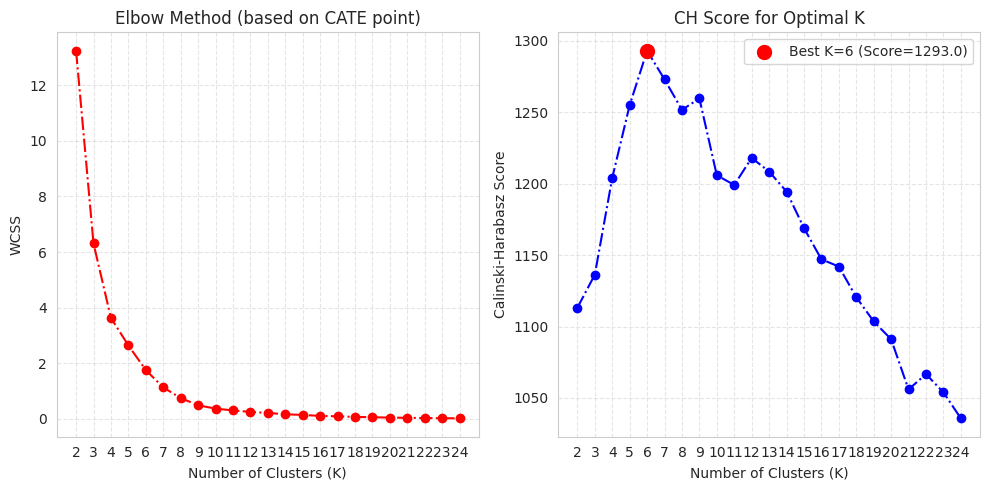

In [16]:
# --- 6a. 肘部法则图 ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='-.', color='red')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method (based on CATE point)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)

# --- 6b. CH 分数图 ---
plt.subplot(1, 2, 2)
valid_k = [k for k, score in zip(k_range, hc_metrics) if not np.isnan(score)]
valid_scores = [score for score in hc_metrics if not np.isnan(score)]

if valid_scores:
    plt.plot(valid_k, valid_scores, marker='o', linestyle='-.', color='blue')
    best_k_ch = valid_k[np.argmax(valid_scores)]
    max_score = np.max(valid_scores)
    plt.scatter(best_k_ch, max_score, color='red', s=100, zorder=5,
                label=f'Best K={best_k_ch} (Score={max_score:.1f})')
    plt.legend()
else:
    best_k_ch = -1

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.title('CH Score for Optimal K')
plt.xticks(valid_k)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig_path = os.path.join(IMG_DIR, "18_hte_dml_cluster_evaluation.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
# plt.show()
print(f"\n    图片已保存: {fig_path}")


    --- 可视化最优 K=6 聚类结果 ---


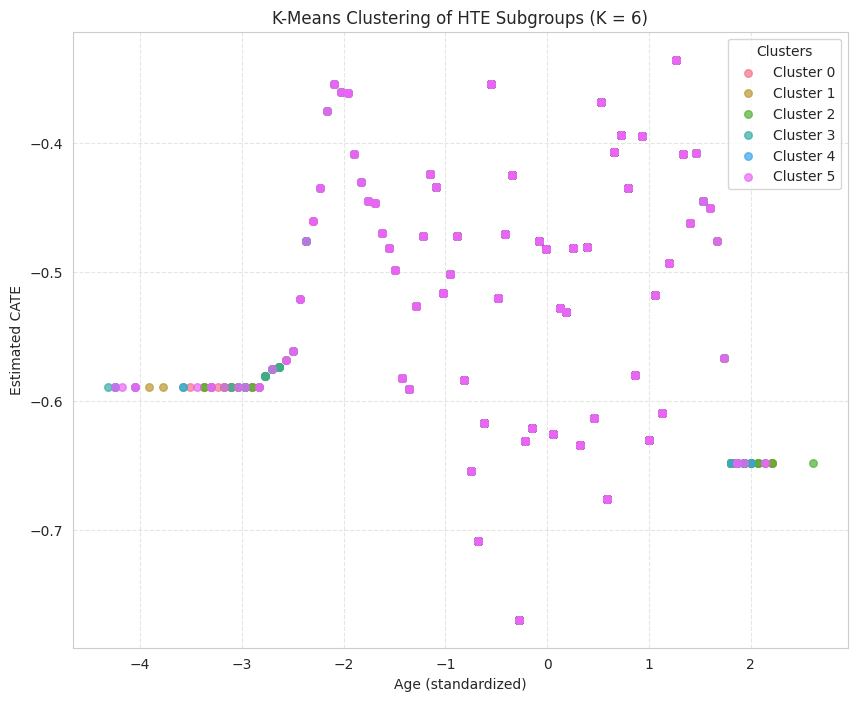

    图片已保存: ../img/18_hte_dml_cluster_result.png

    结果已保存: ../results/18_hte_dml_results.txt


In [17]:
# ============================================================================
# 7. 可视化最优聚类结果
# ============================================================================
if best_k_ch != -1:
    print(f"\n    --- 可视化最优 K={best_k_ch} 聚类结果 ---")
    best_labels = hc_labels[valid_k.index(best_k_ch)]

    plt.figure(figsize=(10, 8))
    palette = sns.color_palette("husl", best_k_ch)

    for i in np.unique(best_labels):
        spots = np.where(best_labels == i)
        plt.scatter(
            total_frame[spots, 3],    # X = Age (standardized)
            total_frame[spots, 2],    # Y = CATE point estimate
            label=f'Cluster {i}',
            color=palette[i],
            alpha=0.7,
            s=30
        )

    plt.xlabel('Age (standardized)')
    plt.ylabel('Estimated CATE')
    plt.title(f'K-Means Clustering of HTE Subgroups (K = {best_k_ch})')
    plt.legend(title='Clusters')
    plt.grid(True, linestyle='--', alpha=0.5)

    fig_path = os.path.join(IMG_DIR, "18_hte_dml_cluster_result.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"    图片已保存: {fig_path}")

    # 聚类描述统计
    with open(res_path, 'a', encoding='utf-8') as f:
        f.write(f"\n--- 最优聚类结果 (K={best_k_ch}) ---\n")
        for i in np.unique(best_labels):
            spots = np.where(best_labels == i)[0]
            f.write(f"\n集群 {i}: 样本数={len(spots)}\n")
            f.write(f"  平均 CATE: {point_orig[spots].mean():.4f} ± {point_orig[spots].std():.4f}\n")
            f.write(f"  平均 Age: {X[spots, 0].mean():.4f}\n")

    print(f"\n    结果已保存: {res_path}")
